# A physiology-preserving adaptive denoising and VMD-based feature extraction framework for gastrointestinal manometry signals

本文将稳健波动估计、信号质量评估以及生理约束型自适应去噪融合为统一的胃肠压力信号预处理框架。


NoiseRatio = MAD(first difference) / MAD(pressure)本文将一阶压力差分的 MAD 与原始压力信号 MAD 的比值定义为稳健高频波动指数，用于表征信号中的快速波动程度

NoiseRatio命名成HFFR = MAD(ΔP) / MAD(P)：
HFFR 越大，说明单位时间内压力快速波动越明显，信号中可能存在更多噪声、尖刺或短时伪影，因此需要更强的平滑或更谨慎的事件判定。

P 是压力信号

ΔP 是一阶差分

MAD 是 median absolute deviation

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from ppvmd_tools.ppvmd_denoising import physiology_preserving_adaptive_denoise
from ppvmd_tools.ppvmd_validation import (
    recommend_adaptive_parameters,
    make_semisynthetic_pressure_dataset,
    evaluate_semisynthetic_result,
)
from ppvmd_tools.ppvmd_vmd import (
    physiology_constrained_vmd_reconstruction,
    summarize_physiology_vmd_result,
    search_best_vmd_parameters,
)

OUTPUT_DIR = Path("paper_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. 数据读取

In [103]:
RAW_DATA_PATH = r"D:\a_work\课题组实验数据处理\电子胶囊临床实验数据\导出数据\2bHT000007.txt"

TIME_COL = "Time"
PH_COL = "PH"
TEMP_COL = "Temperature"
PRESSURE_COL = "Pressure"
PRESSURE_MIN = 85
PRESSURE_MAX = 130
RESAMPLE_DT = 1.2

data_raw = pd.read_csv(
    RAW_DATA_PATH,
    delimiter="\t",
    header=0,
    names=[TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL],
).reset_index(drop=True)

for col in [TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL]:
    data_raw[col] = pd.to_numeric(data_raw[col], errors="coerce")

data_raw = data_raw.dropna(subset=[TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL]).reset_index(drop=True)

colon_data = data_raw.iloc[25000:40900].copy().reset_index(drop=True)
colon_data.head()

,Time,PH,Temperature,Pressure
0,39809.23,8.882,36.549,101.123
1,39810.38,8.265,36.430,101.817
2,39811.52,8.333,36.549,101.865
3,39812.66,8.333,36.537,100.901
4,39813.81,9.088,36.430,100.496


## 2. 自适应预处理降噪

In [104]:
adaptive_result = recommend_adaptive_parameters(
    colon_data,
    time_col=TIME_COL,
    pressure_col=PRESSURE_COL,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
)

allowed_keys = [
    "noise_window_s", "event_amp_k", "event_area_k",
    "amp_k", "slope_k", "curvature_k", "smooth_window_s",
]
adaptive_kwargs = {k: adaptive_result[k] for k in allowed_keys if k in adaptive_result}
quality_metrics = {k: v for k, v in adaptive_result.items() if k not in allowed_keys}

print("自适应参数:", adaptive_kwargs)
print("信号质量:", quality_metrics)

df_out = physiology_preserving_adaptive_denoise(
    colon_data,
    time_col=TIME_COL,
    pressure_col=PRESSURE_COL,
    ph_col=PH_COL,
    temp_col=TEMP_COL,
    resample_dt=RESAMPLE_DT,
    use_hard_range_gate=True,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    **adaptive_kwargs,
)

df_out.head()

自适应参数: {'noise_window_s': 22.233803187973674, 'event_amp_k': 3.1787042550378937, 'event_area_k': 1.6116901593986837, 'amp_k': 6.164929521803949, 'slope_k': 6.164929521803949, 'curvature_k': 6.164929521803949, 'smooth_window_s': 5.470140956392102}
信号质量: {'signal_quality_badness': 0.2233803187973673, 'range_abnormal_ratio': 0.0003773584905660377, 'noise_ratio': 0.34192037434718336}


,Time,PH,Temperature,Pressure_Raw,Pressure_RangeFixed,Pressure_Preclean,Pressure_Clean,Baseline,Residual,LocalNoiseSigma,RangeAbnormalMask,ArtifactMask,PhysioEventMask,QualityFlag
0,39809.23,8.882000,36.549000,101.123000,101.123000,101.123000,101.237362,101.102000,0.135362,0.301927,False,False,False,good
1,39810.43,8.267982,36.435219,101.819105,101.819105,101.819105,101.637869,101.070447,0.567422,0.272665,False,False,False,good
2,39811.63,8.333000,36.547842,101.771982,101.771982,101.771982,101.629520,101.098816,0.530705,0.275125,False,False,False,good
3,39812.83,8.444609,36.521183,100.841130,100.841130,100.841130,100.975415,101.064122,-0.088707,0.276055,False,False,False,good
4,39814.03,9.088000,36.434632,100.548105,100.548105,100.548105,100.595274,101.042368,-0.447095,0.261197,False,False,False,good


## 3. 半合成验证

In [105]:
semi_source = df_out[["Time", "PH", "Temperature", "Baseline", "PhysioEventMask"]].copy()
semi_source["Pressure"] = df_out["Pressure_Clean"].values

semi_df, truth = make_semisynthetic_pressure_dataset(
    semi_source,
    time_col="Time",
    pressure_col="Pressure",
    ph_col="PH",
    temp_col="Temperature",
    event_col="PhysioEventMask",
)

adaptive_result_semi = recommend_adaptive_parameters(
    semi_df, time_col="Time", pressure_col="Pressure",
    pressure_min=PRESSURE_MIN, pressure_max=PRESSURE_MAX,
)
adaptive_kwargs_semi = {k: adaptive_result_semi[k] for k in allowed_keys if k in adaptive_result_semi}

semi_pred_df = physiology_preserving_adaptive_denoise(
    semi_df,
    time_col="Time", pressure_col="Pressure", ph_col="PH", temp_col="Temperature",
    resample_dt=RESAMPLE_DT,
    use_hard_range_gate=True, pressure_min=PRESSURE_MIN, pressure_max=PRESSURE_MAX,
    **adaptive_kwargs_semi,
)

semi_report = evaluate_semisynthetic_result(
    semi_pred_df, truth,
    time_col="Time", clean_col="Pressure_Clean", artifact_col="ArtifactMask", event_col="PhysioEventMask",
)
semi_report["summary"]


,RMSE,Correlation,Artifact_F1,Artifact_Recall,Mean_Event_IoU,Mean_Abs_OnsetError_s,Mean_Abs_OffsetError_s
0,0.081321,0.998942,0.504762,0.634731,0.726398,2.976623,1.932468


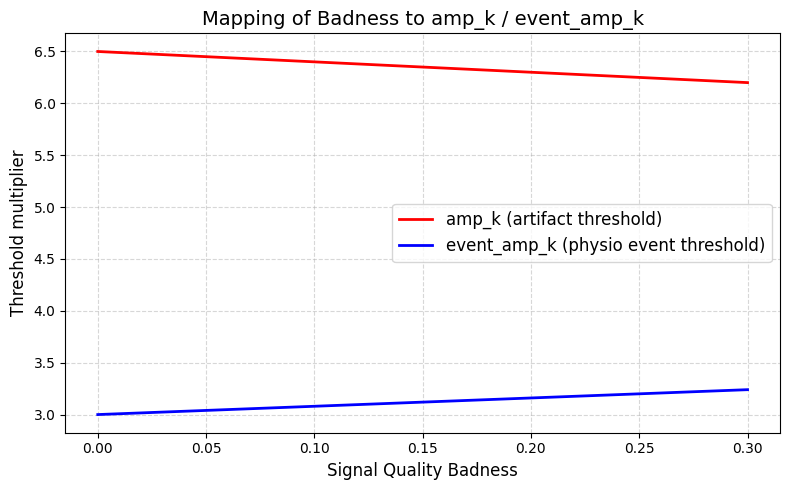

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# 模拟 Badness 范围 0~0.3（你实际可根据数据调整）
badness = np.linspace(0, 0.3, 50)

# amp_k 和 event_amp_k 的经验映射
amp_k = 6.5 - 1.0 * badness
event_amp_k = 3.0 + 0.8 * badness

plt.figure(figsize=(8,5))
plt.plot(badness, amp_k, label="amp_k (artifact threshold)", color='red', linewidth=2)
plt.plot(badness, event_amp_k, label="event_amp_k (physio event threshold)", color='blue', linewidth=2)
plt.xlabel("Signal Quality Badness", fontsize=12)
plt.ylabel("Threshold multiplier", fontsize=12)
plt.title("Mapping of Badness to amp_k / event_amp_k", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [107]:
# #直接参考下列热图
# #新增参数敏感性实验：该数据样本敏感性实验表明，算法鲁棒性高，不会因为 w_noise / w_range 小幅调节而导致信号失真或事件丢失。

# import numpy as np
# import pandas as pd

# def recommend_adaptive_parameters_with_weights(
#     data,
#     time_col="Time",
#     pressure_col="Pressure",
#     pressure_min=85.0,
#     pressure_max=130.0,
#     w_noise=0.65,
#     w_range=3.0,
# ):
#     """
#     带权重版本的自适应参数推荐函数。
#     用于 Badness 参数敏感性实验。
#     """

#     df = data[[time_col, pressure_col]].replace([np.inf, -np.inf], np.nan).dropna()
#     df = df.sort_values(time_col)

#     t = df[time_col].to_numpy(dtype=float)
#     p = df[pressure_col].to_numpy(dtype=float)

#     dt = np.median(np.diff(t))

#     def robust_mad(x, scale=True, eps=1e-12):
#         x = np.asarray(x, dtype=float)
#         x = x[np.isfinite(x)]
#         med = np.median(x)
#         mad = np.median(np.abs(x - med))
#         if scale:
#             mad *= 1.4826
#         return max(mad, eps)

#     dp = np.diff(p)

#     pressure_scale = robust_mad(p)
#     diff_scale = robust_mad(dp)

#     range_abnormal_ratio = np.mean(
#         (p < pressure_min) | (p > pressure_max)
#     )

#     noise_ratio = diff_scale / (pressure_scale + 1e-9)

#     quality_badness = np.clip(
#         w_noise * noise_ratio + w_range * range_abnormal_ratio,
#         0.0,
#         1.0
#     )

#     amp_k = 6.5 - 1.0 * quality_badness
#     slope_k = 6.5 - 1.0 * quality_badness
#     curvature_k = 6.5 - 1.0 * quality_badness

#     event_amp_k = 3.0 + 0.8 * quality_badness
#     event_area_k = 1.5 + 0.5 * quality_badness

#     smooth_window_s = max(3.0 * dt, 4.8 + 3.0 * quality_badness)
#     noise_window_s = max(10.0 * dt, 20.0 + 10.0 * quality_badness)

#     return {
#         "noise_window_s": float(noise_window_s),
#         "event_amp_k": float(event_amp_k),
#         "event_area_k": float(event_area_k),
#         "amp_k": float(amp_k),
#         "slope_k": float(slope_k),
#         "curvature_k": float(curvature_k),
#         "smooth_window_s": float(smooth_window_s),
#         "signal_quality_badness": float(quality_badness),
#         "range_abnormal_ratio": float(range_abnormal_ratio),
#         "noise_ratio": float(noise_ratio),
#         "w_noise": float(w_noise),
#         "w_range": float(w_range),
#     }

# def run_badness_weight_sensitivity(
#     semi_df,
#     truth,
#     w_noise_list=None,
#     w_range_list=None,
# ):
#     """
#     Badness 权重敏感性实验。

#     目的：
#     测试 w_noise 和 w_range 变化时，最终去噪效果是否稳定。
#     """

#     if w_noise_list is None:
#         w_noise_list = [0.45, 0.55, 0.65, 0.75, 0.85]

#     if w_range_list is None:
#         w_range_list = [1.0, 2.0, 3.0, 4.0, 5.0]

#     allowed_keys = [
#         "noise_window_s",
#         "event_amp_k",
#         "event_area_k",
#         "amp_k",
#         "slope_k",
#         "curvature_k",
#         "smooth_window_s"
#     ]

#     rows = []

#     for w_noise in w_noise_list:
#         for w_range in w_range_list:

#             adaptive_result = recommend_adaptive_parameters_with_weights(
#                 semi_df,
#                 time_col="Time",
#                 pressure_col="Pressure",
#                 pressure_min=85,
#                 pressure_max=130,
#                 w_noise=w_noise,
#                 w_range=w_range,
#             )

#             adaptive_kwargs = {
#                 k: adaptive_result[k]
#                 for k in allowed_keys
#                 if k in adaptive_result
#             }

#             pred_df_tmp = physiology_preserving_adaptive_denoise(
#                 semi_df,
#                 time_col="Time",
#                 pressure_col="Pressure",
#                 ph_col="PH",
#                 temp_col="Temperature",
#                 resample_dt=1.2,
#                 pressure_min=85,
#                 pressure_max=130,
#                 **adaptive_kwargs
#             )

#             report_tmp = evaluate_semisynthetic_result(
#                 pred_df_tmp,
#                 truth,
#                 time_col="Time",
#                 clean_col="Pressure_Clean",
#                 artifact_col="ArtifactMask",
#                 event_col="PhysioEventMask"
#             )

#             summary = report_tmp["summary"].iloc[0].to_dict()

#             row = {
#                 "w_noise": w_noise,
#                 "w_range": w_range,
#                 "Badness": adaptive_result["signal_quality_badness"],
#                 "NoiseRatio": adaptive_result["noise_ratio"],
#                 "RangeAbnormalRatio": adaptive_result["range_abnormal_ratio"],
#                 "amp_k": adaptive_result["amp_k"],
#                 "event_amp_k": adaptive_result["event_amp_k"],
#                 "smooth_window_s": adaptive_result["smooth_window_s"],
#                 **summary
#             }

#             rows.append(row)

#             print(
#                 f"Done w_noise={w_noise}, w_range={w_range}, "
#                 f"RMSE={summary['RMSE']:.4f}, "
#                 f"Corr={summary['Correlation']:.4f}, "
#                 f"EventIoU={summary['Mean_Event_IoU']:.4f}"
#             )

#     result_df = pd.DataFrame(rows)

#     result_df = result_df.sort_values(
#         by=["RMSE", "Mean_Event_IoU"],
#         ascending=[True, False]
#     ).reset_index(drop=True)

#     return result_df

# sensitivity_result = run_badness_weight_sensitivity(
#     semi_df=semi_df,
#     truth=truth,
#     w_noise_list=[0.45, 0.55, 0.65, 0.75, 0.85],
#     w_range_list=[1.0, 2.0, 3.0, 4.0, 5.0]
# )

# sensitivity_result

In [108]:
# #热图绘制
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# def plot_sensitivity_heatmap(
#     df,
#     value_col,
#     title=None,
#     cmap="cividis",
#     fmt=".3f",
#     save_path=None
# ):
#     """
#     绘制参数敏感性热图（适用于 RMSE、Event IoU、Artifact F1）
    
#     Parameters
#     ----------
#     df : DataFrame
#         包含 w_noise, w_range 和指标列的数据
#     value_col : str
#         要绘制的指标列名，例如 "RMSE", "Mean_Event_IoU", "Artifact_F1"
#     title : str, optional
#         图标题
#     cmap : str
#         matplotlib colormap
#     fmt : str
#         文本标注的格式
#     save_path : str, optional
#         保存路径，若 None 则不保存
#     """

#     df = df.copy()
#     df["w_noise"] = df["w_noise"].astype(float)
#     df["w_range"] = df["w_range"].astype(float)

#     pivot = df.pivot_table(
#         index="w_noise",
#         columns="w_range",
#         values=value_col,
#         aggfunc="mean"
#     )

#     pivot = pivot.sort_index(axis=0).sort_index(axis=1)
#     values = pivot.values.astype(float)

#     fig, ax = plt.subplots(figsize=(8, 5))
#     vmin = np.nanmin(values)
#     vmax = np.nanmax(values)

#     im = ax.imshow(
#         values,
#         aspect="auto",
#         cmap=cmap,
#         vmin=vmin,
#         vmax=vmax
#     )

#     cbar = plt.colorbar(im, ax=ax)
#     cbar.set_label(value_col, fontsize=12)

#     # ticks
#     ax.set_xticks(np.arange(len(pivot.columns)))
#     ax.set_xticklabels([f"{x:.1f}" for x in pivot.columns])
#     ax.set_yticks(np.arange(len(pivot.index)))
#     ax.set_yticklabels([f"{y:.2f}" for y in pivot.index])

#     ax.set_xlabel("w_range", fontsize=12)
#     ax.set_ylabel("w_noise", fontsize=12)
#     if title is not None:
#         ax.set_title(title, fontsize=14)

#     # 自动字体颜色
#     threshold = (vmin + vmax) / 2
#     for i in range(values.shape[0]):
#         for j in range(values.shape[1]):
#             val = values[i, j]
#             text_color = "black" if val > threshold else "white"
#             ax.text(
#                 j,
#                 i,
#                 f"{val:{fmt}}",
#                 ha="center",
#                 va="center",
#                 color=text_color,
#                 fontsize=10,
#                 fontweight="bold"
#             )

#     # 网格线
#     ax.set_xticks(np.arange(-0.5, len(pivot.columns), 1), minor=True)
#     ax.set_yticks(np.arange(-0.5, len(pivot.index), 1), minor=True)
#     ax.grid(which="minor", color="white", linestyle="-", linewidth=1.0)
#     ax.tick_params(which="minor", bottom=False, left=False)

#     plt.tight_layout()

#     if save_path is not None:
#         plt.savefig(save_path, dpi=300, bbox_inches="tight")

#     plt.show()
#     return pivot

In [109]:
# # RMSE 热图
# plot_sensitivity_heatmap(
#     sensitivity_result,
#     value_col="RMSE",
#     title="Sensitivity of RMSE to Badness Weights",
#     cmap="viridis"
# )

# # Event IoU 热图 /cividis
# plot_sensitivity_heatmap(
#     sensitivity_result,
#     value_col="Mean_Event_IoU",
#     title="Sensitivity of Event IoU to Badness Weights",
#     cmap="viridis"
# )

# # Artifact F1 热图
# plot_sensitivity_heatmap(
#     sensitivity_result,
#     value_col="Artifact_F1",
#     title="Sensitivity of Artifact F1 to Badness Weights",
#     cmap="viridis"
# )

## 4. 生理约束型 VMD

In [113]:
MIN_KEEP_SCORE = 0.18
MAIN_K = 6
MAIN_ALPHA = 2000

main_vmd = physiology_constrained_vmd_reconstruction(
    signal=df_out["Pressure_Clean"].values,
    time=df_out["Time"].values,
    event_mask=df_out["PhysioEventMask"].values,
    artifact_mask=df_out["ArtifactMask"].values,
    K=MAIN_K,
    alpha=MAIN_ALPHA,
    min_keep_score=MIN_KEEP_SCORE,
)

main_mode_summary = summarize_physiology_vmd_result(main_vmd)
main_mode_summary

,Mode,DominantFreq_Hz,EnergyRatio,SignalCorrelation,EventCorrelation,EventEnergyRatio,ArtifactEnergyRatio,SpectralEntropy,Kurtosis,TemporalContinuity,PhysioKeepScore,Selected
0,1,0.000052,0.687053,0.856758,0.487005,0.158390,0.097716,0.276384,5.708519,0.999953,0.457643,True
1,2,0.006270,0.081630,0.398231,0.307544,0.343225,0.117256,0.577118,17.876469,0.994064,0.251165,True
2,3,0.021971,0.060491,0.329822,0.748510,0.393235,0.143206,0.599217,22.013885,0.966717,0.329068,True
3,4,0.054512,0.022376,0.220647,0.406270,0.272685,0.141866,0.657293,19.674309,0.868642,0.180337,True
4,5,0.087727,0.017211,0.188425,0.293906,0.192129,0.089544,0.663038,14.000117,0.708121,0.144169,False
5,6,0.119803,0.007873,0.143706,0.205523,0.170146,0.068650,0.695697,10.006961,0.559635,0.106340,False


## 5. K-alpha 参数搜索

In [ ]:
# K_list = [3, 4, 5, 6, 7]
# alpha_list = [1500, 2000, 2500, 2700, 3000, 3500]

# vmd_param_search_result = search_best_vmd_parameters(
#     pred_df=df_out,
#     signal_col="Pressure_Clean",
#     K_list=K_list,
#     alpha_list=alpha_list,
#     min_keep_score=MIN_KEEP_SCORE,
# )

# vmd_param_search_result.head(10)

Done: K=3, alpha=1500, Score=0.8958, RMSE=0.4590, Corr=0.9667, Modes=[1, 2]
Done: K=3, alpha=2000, Score=0.8885, RMSE=0.4723, Corr=0.9647, Modes=[1, 2]
Done: K=3, alpha=2500, Score=0.8820, RMSE=0.4835, Corr=0.9631, Modes=[1, 2]
Done: K=3, alpha=2700, Score=0.8798, RMSE=0.4875, Corr=0.9625, Modes=[1, 2]
Done: K=3, alpha=3000, Score=0.8762, RMSE=0.4933, Corr=0.9616, Modes=[1, 2]
Done: K=3, alpha=3500, Score=0.8714, RMSE=0.5023, Corr=0.9602, Modes=[1, 2]
Done: K=4, alpha=1500, Score=0.9335, RMSE=0.3767, Corr=0.9777, Modes=[1, 2, 3]
Done: K=4, alpha=2000, Score=0.9271, RMSE=0.3882, Corr=0.9764, Modes=[1, 2, 3]
Done: K=4, alpha=2500, Score=0.9215, RMSE=0.3980, Corr=0.9752, Modes=[1, 2, 3]
Done: K=4, alpha=2700, Score=0.9191, RMSE=0.4016, Corr=0.9748, Modes=[1, 2, 3]
Done: K=4, alpha=3000, Score=0.9157, RMSE=0.4069, Corr=0.9742, Modes=[1, 2, 3]
Done: K=4, alpha=3500, Score=0.9111, RMSE=0.4152, Corr=0.9731, Modes=[1, 2, 3]
Done: K=5, alpha=1500, Score=0.9283, RMSE=0.3969, Corr=0.9752, Modes=[

,K,alpha,min_keep_score,RMSE,RMSE_Norm,Correlation,Mean_Event_IoU,Mean_PeakPreservationRatio,Mean_AreaPreservationRatio,NumEvents,NumSelectedModes,SelectedModes,ObjectiveScore
0,7,1500,0.18,0.390937,0.023043,0.975773,0.994369,0.793221,0.876477,78,4,"[1, 2, 3, 4]",0.937511
1,6,2000,0.18,0.386330,0.022772,0.976384,0.994369,0.789585,0.872675,78,4,"[1, 2, 3, 4]",0.936616
2,7,2000,0.18,0.395074,0.023287,0.975277,0.994369,0.783339,0.866504,78,4,"[1, 2, 3, 4]",0.934348
3,4,1500,0.18,0.376659,0.022202,0.977706,0.993453,0.780802,0.858856,78,3,"[1, 2, 3]",0.933515
4,6,2500,0.18,0.391362,0.023068,0.975783,0.994369,0.779539,0.862655,78,4,"[1, 2, 3, 4]",0.933382
5,6,2700,0.18,0.393225,0.023178,0.975560,0.994369,0.775809,0.858876,78,4,"[1, 2, 3, 4]",0.932172
6,7,2500,0.18,0.399043,0.023521,0.974799,0.994369,0.774158,0.857153,78,4,"[1, 2, 3, 4]",0.931390
7,6,3000,0.18,0.395903,0.023336,0.975238,0.994369,0.770484,0.853407,78,4,"[1, 2, 3, 4]",0.930433
8,7,2700,0.18,0.400612,0.023614,0.974608,0.994369,0.770614,0.853547,78,4,"[1, 2, 3, 4]",0.930247
9,7,3000,0.18,0.402978,0.023753,0.974320,0.994369,0.765398,0.848239,78,4,"[1, 2, 3, 4]",0.928561


当 K 超过 6 后，并未出现新的稳定生理模态，说明对于当前胃肠动力数据而言，K=6 已经达到最小充分分解复杂度。

## 6. 结果导出

In [ ]:
df_out.to_csv(OUTPUT_DIR / "denoised_signal.csv", index=False)
main_mode_summary.to_csv(OUTPUT_DIR / "final_vmd_mode_summary.csv", index=False)
# vmd_param_search_result.to_csv(OUTPUT_DIR / "vmd_parameter_search_result.csv", index=False)
print("Exported to", OUTPUT_DIR.resolve())

Exported to D:\a_work\课题组实验数据处理\新预处理\paper_outputs
